In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
rul_fi = pd.read_csv('../data/feature_importance_rul.csv')
knee_fi = pd.read_csv('../data/feature_importance_kneepoint.csv')

In [3]:
knee_fi

,Unnamed: 0,feature_name,score,seed
0,0,identity(nanvar(Cycle(1/5) - Cycle(3/5))[nanma...,0.017690,0
1,1,abs(nanmean(Cycle(1/5))[nanmean(QV_c(3/4))]),0.015220,0
2,2,identity(nanmean(Cycle(1/5) - Cycle(5/5))[nanv...,0.008858,0
3,3,identity(nanmax(Cycle(1/5))[nanmean(VQ_d(3/4))]),0.008854,0
4,4,identity(nanvar(Cycle(1/5) - Cycle(2/5))[nanma...,0.008791,0
5,5,identity(nanmean(Cycle(1/5))[nankurtosis(E_c(1...,0.008336,0
6,6,abs(nanmax(Cycle(1/5))[nanmax(VQ_c(2/4))]),0.008333,0
7,7,abs(nanmean(Cycle(4/5))[nanvar(VQ_d(1/4))]),0.008333,0
8,8,identity(nanmin(Cycle(2/5))[nanmin(V_d(3/4))]),0.008333,0
9,9,identity(nanmean(Cycle(3/5))[nanskew(VQ_d(1/4))]),0.008328,0


In [4]:
def get_imp(fea_imp):
    fea_imp = fea_imp.head(20)
    discharge_score = 0
    charge_score = 0
    charge_count=0
    for idx, i in fea_imp.iterrows():
        # print(i['feature_name'], i['score'])
        if '_d' in i['feature_name']:
            discharge_score += i['score']
        else:
            charge_count +=1
            charge_score += i['score']
    # print(charge_count)
    return discharge_score, charge_score, charge_count

In [5]:
rul_discharge_score, rul_charge_score, rul_charge_count = get_imp(rul_fi)
rul_discharge_score, rul_charge_score, rul_charge_count

(0.303941403, 0.014226778, 1)

In [6]:
knee_discharge_score, knee_charge_score, knee_charge_count = get_imp(knee_fi)
knee_discharge_score, knee_charge_score, knee_charge_count

(0.1023106621038272, 0.0804742008081611, 9)

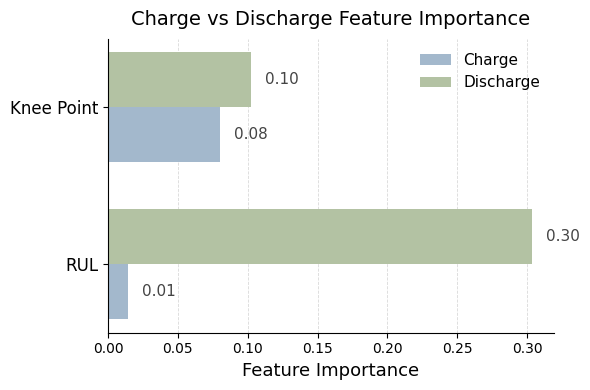

In [14]:
# ==== 莫兰迪色系（低饱和度中性色）====
# morandi_colors = [
#     (194/255, 172/255, 153/255),   # 莫兰迪粉棕（柔和温暖）
#     (157/255, 176/255, 190/255),   # 莫兰迪蓝灰（清冷柔和）
# ]
morandi_colors = [
    (163/255, 184/255, 204/255),  # 柔蓝灰（Dusty Blue）
    (179/255, 194/255, 163/255),  # 浅鼠尾草绿（Sage Green）
]
# ==== 数据（替换为你的真实数值）====
tasks = ['RUL', 'Knee Point']
charge = [rul_charge_score, knee_charge_score]
discharge = [rul_discharge_score, knee_discharge_score]

# morandi_colors = [
#     (142/255, 161/255, 178/255),  # 钢灰蓝（Steel Blue Gray）
#     (167/255, 170/255, 144/255),  # 灰金绿（Olive Sage）
# ]

# ==== 绘图 ====
bar_width = 0.35
y = np.arange(len(tasks))
fig, ax = plt.subplots(figsize=(6, 4))

ax.barh(y - bar_width/2, charge, height=bar_width, label='Charge', color=morandi_colors[0])
ax.barh(y + bar_width/2, discharge, height=bar_width, label='Discharge', color=morandi_colors[1])
ax.grid(axis='x', linestyle='--', linewidth=0.6, color='0.85')
ax.set_axisbelow(True)  # ensures bars appear above grid
# 坐标与标签
ax.set_yticks(y)
ax.set_yticklabels(tasks, fontsize=12)
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('Charge vs Discharge Feature Importance', fontsize=14, pad=10)

# 添加数值标签
for i, (c, d) in enumerate(zip(charge, discharge)):
    ax.text(c + 0.01, i - bar_width/2, f'{c:.2f}', va='center', ha='left', fontsize=11, color='#444444')
    ax.text(d + 0.01, i + bar_width/2, f'{d:.2f}', va='center', ha='left', fontsize=11, color='#444444')

# 去掉多余边框，突出横向美感
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('../output/charge_discharge_feature_importance.png', dpi=300)
plt.show()






